In [1]:
import sys
import os
import pandas as pd
import numpy as np
from pycox.models.cox import CoxPH
from pycox.evaluation import EvalSurv
import matplotlib.pyplot as plt
import torchtuples as tt
import shap
import scipy.integrate
scipy.integrate.simps = scipy.integrate.simpson



from itertools import product
import torch

sys.path.append(os.path.abspath("../../"))
from src.dataset.generate_dataset import TorchPreprocessing
from src.utils.kapplan_meir import k_m_cox
from src.dataset.DataSet import SurvivalDataSet
from src.utils.Preprocessing import Preprocessor
from src.utils.ConvertTextToCsv import TextToCsv
from src.utils.set_seed import set_seed
from src.utils.cox_models import *



import numpy as np
import torch


%load_ext autoreload
%autoreload 2
%matplotlib inline

c:\Users\alexf\Desktop\UPSA_Thesis\UPSA_Thesis_Research\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
set_seed(42)

In [5]:
pp = Preprocessor()

#### Preprocessing of the Data

In [6]:
df_clinical_data = pd.read_csv("../../data/raw/brca_tcga_pub2015_clinical_data.tsv", sep='\t')
df_clinical_data = pp.clean_columns_dataset(df_clinical_data)
list_df = pp.total_type_len_type_cancer(df_clinical_data)
df_clinical_data["Tumor-Cancer"] = list_df
df_clinical_data["Tumor-Cancer"].unique()

df_mRNA_raw_data = TextToCsv("../../data/raw/data_mrna_seq_v2_rsem.txt")


Luminal A: 330 - Total(%): 0.40
Luminal B: 81 - Total(%):0.10
HER2-enriched: 23 - Total(%):0.03
TNBC: 85 - Total(%)0.10 
UNK: 298 - Total(%) 0.36
Shape of the CSV: (20440, 819)


In [7]:
df_merged = TorchPreprocessing(df_mRNA_raw_data,df_clinical_data, 23360).get_comparation_df()
 
comparation_df = df_merged.loc[
    df_merged["Tumor-Cancer"].isin(["Luminal A", "Luminal B", "TNBC", "HER2-enriched"]),
]

comparation_df["Tumor-Cancer"].unique()

print(f"Samples: {comparation_df.shape[0]}, Genes: {comparation_df.shape[1]}")

Genes before Treshold: 20434
count    20434.000000
mean        73.977831
std        155.539160
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        519.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 18533
Samples: 519, Genes: 18534


In [8]:
zero_reduced_df =  comparation_df.drop(["Sample ID"], axis=1)
results_df, desing, expr = pp.initialize_limma(zero_reduced_df, column="Tumor-Cancer", column_event="Overall Survival (Months)", column_status="Overall Survival Status")

In [9]:
results_df

,HER2-enriched,Luminal A,Luminal B,AveExpr,F,pvalue,adj_pvalue
YTHDF1,10.704586,10.782180,10.716942,10.726453,3476.858574,0.000000e+00,0.000000e+00
CNDP2,11.936759,11.938379,11.847431,11.931849,3435.182085,0.000000e+00,0.000000e+00
C9orf72,7.709659,7.473524,7.832910,7.682044,3325.221162,0.000000e+00,0.000000e+00
CDK17,9.816950,9.735724,8.875606,9.626052,3695.732951,0.000000e+00,0.000000e+00
SETD4,8.155403,8.046199,8.155815,8.141270,3396.839510,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...
SLC28A2,0.277010,0.242954,0.086340,0.243943,14.846553,1.159021e-09,1.159271e-09
SSX6,0.132164,0.226988,0.328592,0.195638,14.669272,1.503423e-09,1.503666e-09
TMEM229A,0.207897,0.218256,0.103054,0.198622,14.233538,2.848866e-09,2.849174e-09
GADL1,0.142536,0.159804,0.223690,0.175297,13.301483,1.116376e-08,1.116436e-08


In [10]:
N_GENES = 1000
top_genes_limma = results_df.sort_values("pvalue").index[:N_GENES].tolist()

In [11]:
torch_preprocessing = TorchPreprocessing(df_mRNA_raw_data, df_clinical_data, 23360)
torch_preprocessing.genes_expression = top_genes_limma
genes_expression = top_genes_limma
X_scaled, durations, events, scaler, sample_ids = torch_preprocessing.get_data_set(60, return_ids=True)


Genes before Treshold: 1003
count    1003.000000
mean        1.014955
std         4.878440
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        94.000000
dtype: float64
Threshold (>80% zeros): 415 samples
After the treshold: 1003


In [12]:
X_scaled.shape

(519, 1000)

In [13]:
surival_data_set  = SurvivalDataSet(X_scaled, durations, events)

In [14]:
import json
from src.dataset.split_data import split_dataset_by_ids

# Load the canonical split created by limma.ipynb so the NN uses the SAME patients.
split = json.load(open("splits.json"))
set_seed()
(train_X, train_durations, train_events), \
(val_X, val_durations, val_events), \
(test_X, test_durations, test_events) = split_dataset_by_ids(
    surival_data_set, sample_ids,
    split["train_ids"], split["val_ids"], split["test_ids"]
)
print(f"Train: {train_X.shape[0]}, Val: {val_X.shape[0]}, Test: {test_X.shape[0]}")

Train: 331, Val: 84, Test: 104


In [15]:
train_X.shape

torch.Size([331, 1000])

### Grid Search Hyperparameters for the DeepSurv(Pycox CoxPH)

In [93]:
from itertools import product

in_features = train_X.shape[1]
output_bias = False
param_grid = {
    "num_nodes": [
        [16], [32], [64], [128], [256],
        [16, 16], [32, 16], [32, 32], [64, 32],
    ],
    "dropout": [0.2,0.3, 0.4],
    "batch_norm": [True, False],
    "lr": [1e-3, 5e-4, 1e-4, 1e-5],
    "weight_decay": [0, 1e-4, 1e-3],
    "batch_size": [128, 256, 512],
}
grid = list(product(
    param_grid["num_nodes"],
    param_grid["dropout"],
    param_grid["batch_norm"],
    param_grid["lr"],
    param_grid["weight_decay"],
    param_grid["batch_size"],
))

### Grid Search for the DeepSurv(Pycox CoxPH)

In [95]:
from pycox.evaluation import EvalSurv

best_score = -1
best_params = None
grid_results = []

set_seed()
val_X = np.array(val_X)
val_durations = np.array(val_durations)
val_events = np.array(val_events).astype(bool)

for num_nodes, dp, bn, lr, wd, batch_size in grid:
    try:
        net = tt.torchtuples.practical.MLPVanilla(
            in_features=in_features,
            num_nodes=num_nodes,
            out_features=1,
            dropout=dp,
            output_bias=False,
            batch_norm=bn,
        )
        model_gs = CoxPH(net, tt.torchtuples.optim.Adam(lr=lr, weight_decay=wd))
        
        callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=40)]
        model_gs.fit(
            input=train_X,
            target=(train_durations, train_events),
            batch_size=batch_size,
            epochs=150,
            callbacks=callbacks,
            verbose=False,
            val_data=(val_X, (val_durations, val_events)),
            val_batch_size=batch_size
        )
        
        
        model_gs.compute_baseline_hazards()
        surv_val = model_gs.predict_surv_df(val_X)
        ev = EvalSurv(surv_val, val_durations, val_events, censor_surv='km')
        c_index = ev.concordance_td()

        grid_results.append({
            'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
            'lr': lr, 'weight_decay': wd, 'batch_size': batch_size,
            'c_index': c_index
        })

        if c_index > best_score:
            best_score = c_index
            best_params = {
                'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
                'lr': lr, 'weight_decay': wd, 'batch_size': batch_size
            }
    except Exception as e:
        continue

print(f"Mejor C-index en validación: {best_score:.4f}")
print(f"Mejores parámetros: {best_params}")

Mejor C-index en validación: 0.8184
Mejores parámetros: {'num_nodes': [32, 16], 'dropout': 0.3, 'batch_norm': True, 'lr': 0.001, 'weight_decay': 0, 'batch_size': 128}


Training the Model

In [96]:

out_features = 1
num_nodes = best_params['num_nodes']
dropout = 0.4
batch_norm = best_params['batch_norm']
lr = best_params['lr']
weight_decay = best_params['weight_decay']
batch_size = best_params['batch_size']


net = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, 
    num_nodes=num_nodes, 
    out_features=out_features, 
    batch_norm=batch_norm,
    dropout=dropout,
    output_bias=output_bias
)
model = CoxPH(net, tt.torchtuples.optim.Adam(weight_decay=weight_decay))


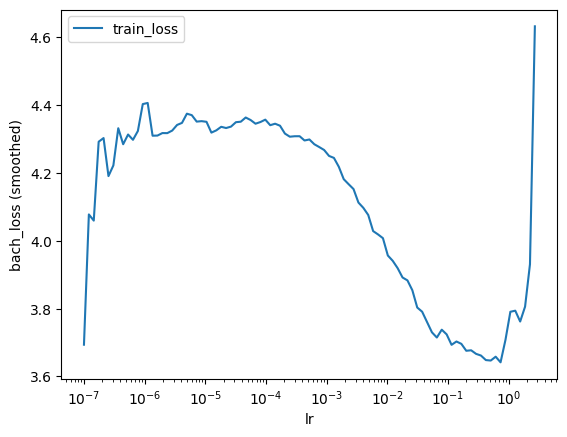

In [97]:
batch_size = batch_size
lrfinder = model.lr_finder(input=train_X,
                           target=(train_durations, train_events),
                           batch_size=batch_size,
                           tolerance=20)

_ = lrfinder.plot()

In [98]:
train_durations.shape

torch.Size([331])

In [99]:
model.optimizer.set_lr(lr)


In [100]:
epochs = 500
callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=35)]
verbose = True

### Training of model (Pycox CoxPH)

In [101]:
%%time

set_seed()
torch.manual_seed(42)
np.random.seed(42)
log = model.fit(input=train_X, target=(train_durations, train_events), epochs=epochs, callbacks=callbacks, verbose=verbose, 
                val_data=(val_X,( val_durations, val_events)), val_batch_size=batch_size)

0:	[0s / 0s],		train_loss: 4.2825,	val_loss: 3.6105
1:	[0s / 0s],		train_loss: 4.1834,	val_loss: 3.5685
2:	[0s / 0s],		train_loss: 4.0435,	val_loss: 3.5509
3:	[0s / 0s],		train_loss: 3.8606,	val_loss: 3.5298
4:	[0s / 0s],		train_loss: 3.2258,	val_loss: 3.4974
5:	[0s / 0s],		train_loss: 3.7738,	val_loss: 3.4697
6:	[0s / 0s],		train_loss: 3.6415,	val_loss: 3.4564
7:	[0s / 0s],		train_loss: 3.9491,	val_loss: 3.4474
8:	[0s / 0s],		train_loss: 3.8678,	val_loss: 3.4565
9:	[0s / 0s],		train_loss: 3.6799,	val_loss: 3.4719
10:	[0s / 0s],		train_loss: 3.5487,	val_loss: 3.4847
11:	[0s / 0s],		train_loss: 3.4947,	val_loss: 3.4955
12:	[0s / 0s],		train_loss: 3.3314,	val_loss: 3.4946
13:	[0s / 0s],		train_loss: 3.5451,	val_loss: 3.4927
14:	[0s / 0s],		train_loss: 3.3465,	val_loss: 3.4897
15:	[0s / 0s],		train_loss: 3.4484,	val_loss: 3.4836
16:	[0s / 0s],		train_loss: 3.2389,	val_loss: 3.4805
17:	[0s / 0s],		train_loss: 3.2245,	val_loss: 3.4756
18:	[0s / 0s],		train_loss: 3.3239,	val_loss: 3.4741
19:

(84, 1000)

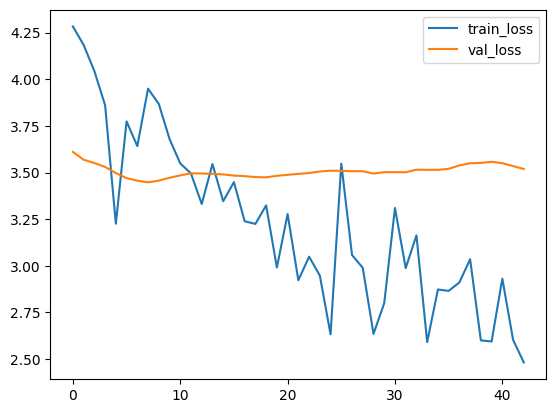

In [102]:
_ = log.plot()
val_X.shape

#### K-M for the Training dataset

In [103]:
risk_nn_train = model.net(train_X).flatten()

list_risk_train = []
for i in risk_nn_train:
    list_risk_train.append(i.item())
    


For this group the risk High

For the time 0 the risk group is 164
For the time 12 the risk group is 138
For the time 24 the risk group is 80
For the time 36 the risk group is 52
For the time 48 the risk group is 34
For the time 60 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 160
For the time 12 the risk group is 145
For the time 24 the risk group is 91
For the time 36 the risk group is 74
For the time 48 the risk group is 61
For the time 60 the risk group is 0


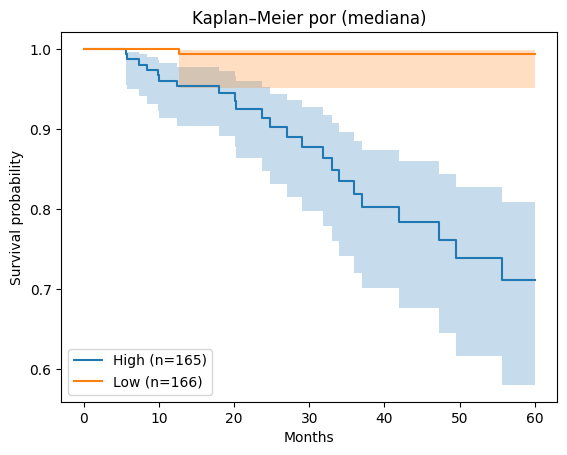

Log-rank: chi2=24.932, p=5.939e-07


(24.93181429748064, 5.939414795082551e-07)

In [104]:
k_m_cox(list_risk_train, train_durations, train_events)

##### Log Rank and chi2 for Training Dataset

#### Log Likehood (The Loss)

In [105]:
model.partial_log_likelihood(*(val_X, (val_durations, val_events))).mean()


-3.4486735

In [106]:
_ = model.compute_baseline_hazards()

In [107]:
surv = model.predict_surv_df(input=test_X)

In [108]:
chf = model.predict_cumulative_hazards(test_X)
chf.shape
#275 → número de puntos de tiempo
#52 -> pacientes 

(220, 104)

#### K-M for the Test dataset

In [109]:
model.net.eval()
with torch.no_grad():
    risk_nn_test = model.net(torch.as_tensor(test_X, dtype=torch.float32)).flatten()

list_risk_test = []
for i in risk_nn_test:
    list_risk_test.append(i.item())



For this group the risk High

For the time 0 the risk group is 52
For the time 12 the risk group is 41
For the time 24 the risk group is 24
For the time 36 the risk group is 15
For the time 48 the risk group is 11
For the time 60 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 51
For the time 12 the risk group is 42
For the time 24 the risk group is 27
For the time 36 the risk group is 19
For the time 48 the risk group is 14
For the time 60 the risk group is 0


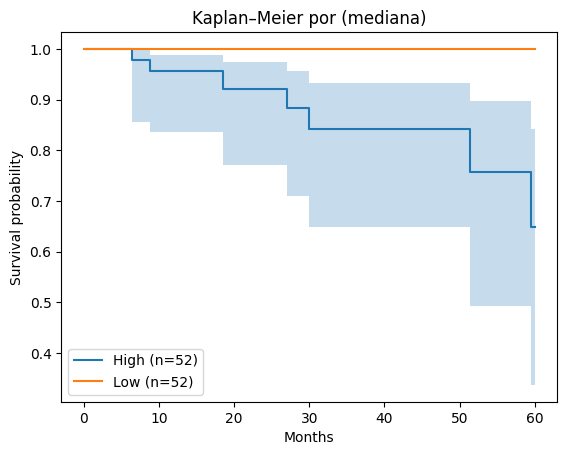

Log-rank: chi2=8.172, p=0.004254


In [110]:
chisq, p_value = k_m_cox(list_risk_test, test_durations, test_events)

Prediction of survival of the Patients

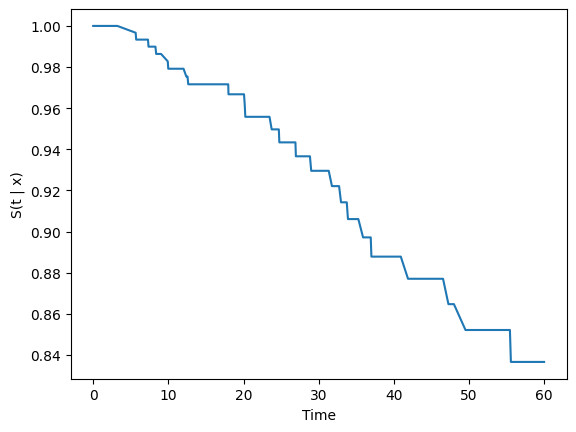

In [111]:
surv.mean(axis=1).plot()
plt.ylabel('S(t | x)')
plt.legend().set_visible(False)
_ = plt.xlabel("Time")

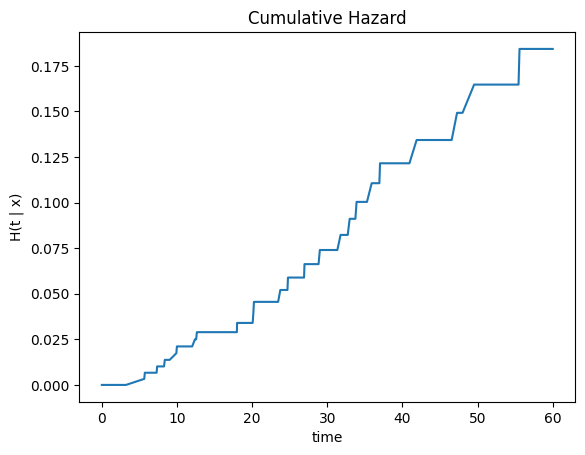

In [112]:
cum_haz = model.predict_cumulative_hazards(test_X)
cuz_model_mean = cum_haz.mean(axis=1)
cuz_model_mean.plot()
plt.xlabel("time")
plt.title("Cumulative Hazard")
plt.ylabel("H(t | x)")
plt.legend().set_visible(False)

In [113]:
test_X = np.array(test_X).astype('float32')
test_durations = np.array(test_durations).flatten()
test_events = np.array(test_events).astype(bool).flatten()

print(f"test_X shape: {test_X.shape}")
print(f"test_durations shape: {test_durations.shape}")
print(f"test_events shape: {test_events.shape}")

test_X shape: (104, 1000)
test_durations shape: (104,)
test_events shape: (104,)


In [114]:
torch.manual_seed(42)
np.random.seed(42)
ev = EvalSurv(surv=surv,
              durations=test_durations,
              events=test_events,
              censor_surv="km")


Concordance of the Model

In [115]:

print(f"Concordance of the model {ev.concordance_td()}")

Concordance of the model 0.8191489361702128


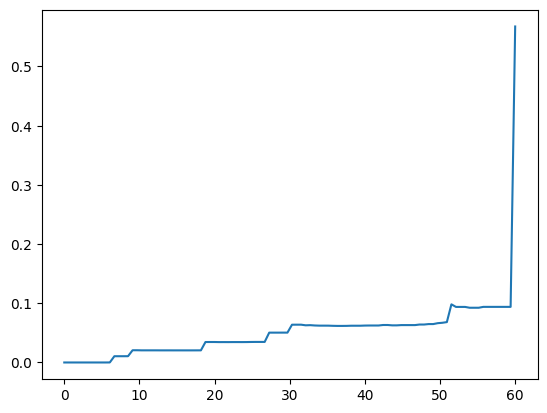

In [116]:
time_grid = np.linspace(test_durations.min(), test_durations.max(), 100)
_ = ev.brier_score(time_grid).plot()

In [117]:
ev.integrated_brier_score(time_grid=time_grid)

0.049386044918638516

In [118]:
ev.integrated_nbll(time_grid)
ci_test_deepsurv = ev.concordance_td()
ibs_deepsurv     = ev.integrated_brier_score(time_grid)

In [134]:
param_grid_cn = {
      "num_nodes":    [[32], [64], [128], [256]],
         "dropout":      [0],
      "batch_norm":   [True, False],
      "lr":           [1e-3, 5e-4, 1e-4],
      "weight_decay": [1e-4, 1e-3, 1e-2],
      "batch_size":   [64, 128, 256],
  }
grid_cn = list(product(
    param_grid_cn["num_nodes"],
    param_grid_cn["dropout"],
    param_grid_cn["batch_norm"],
    param_grid_cn["lr"],
    param_grid_cn["weight_decay"],
    param_grid_cn["batch_size"],
))

best_score_cn  = -1
best_params_cn = None
grid_results_cn = []
set_seed()
for num_nodes, dp, bn, lr, wd, batch_size in grid_cn:
    try:
        net_cn = tt.torchtuples.practical.MLPVanilla(
            in_features  = in_features,
            num_nodes    = num_nodes,       # lista de 1 elemento
            out_features = 1,
            dropout      = dp,
            output_bias  = False,
            batch_norm   = bn,
        )
        model_cn_gs = CoxPH(net_cn, tt.torchtuples.optim.Adam(lr=lr, weight_decay=wd))

        callbacks = [tt.torchtuples.callbacks.EarlyStopping(patience=20)]
        model_cn_gs.fit(
            input      = train_X,
            target     = (train_durations, train_events),
            batch_size = batch_size,
            epochs     = 100,
            callbacks  = callbacks,
            verbose    = False,
            val_data   = (val_X, (val_durations, val_events)),
            val_batch_size = batch_size,
        )

        model_cn_gs.compute_baseline_hazards()
        surv_val_cn = model_cn_gs.predict_surv_df(val_X)
        ev_cn_gs    = EvalSurv(surv_val_cn, val_durations, val_events, censor_surv='km')
        c_index_cn  = ev_cn_gs.concordance_td()

        grid_results_cn.append({
            'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
            'lr': lr, 'weight_decay': wd, 'batch_size': batch_size,
            'c_index': c_index_cn
        })

        if c_index_cn > best_score_cn:
            best_score_cn  = c_index_cn
            best_params_cn = {
                'num_nodes': num_nodes, 'dropout': dp, 'batch_norm': bn,
                'lr': lr, 'weight_decay': wd, 'batch_size': batch_size
            }
    except Exception as e:
        continue

print(f"Mejor C-index en validación (Cox-nnet): {best_score_cn:.4f}")
print(f"Mejores parámetros: {best_params_cn}")

Mejor C-index en validación (Cox-nnet): 0.7816
Mejores parámetros: {'num_nodes': [256], 'dropout': 0, 'batch_norm': False, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 128}


In [135]:
set_seed()
torch.manual_seed(42)
np.random.seed(42)
net_cn = tt.torchtuples.practical.MLPVanilla(
    in_features=in_features, num_nodes=best_params_cn['num_nodes'],
    out_features=1, batch_norm=best_params_cn['batch_norm'],
    dropout=best_params_cn['dropout'], output_bias=False,
)
model_cn = CoxPH(net_cn, tt.torchtuples.optim.Adam(
    lr=best_params_cn['lr'], weight_decay=best_params_cn['weight_decay']
))
model_cn.fit(
    input=train_X, target=(train_durations, train_events),
    batch_size=best_params_cn['batch_size'], epochs=200, verbose=True,
    callbacks=[tt.torchtuples.callbacks.EarlyStopping(patience=30)],
    val_data=(val_X, (val_durations, val_events)),
)

model_cn.compute_baseline_hazards()
surv_cn = model_cn.predict_surv_df(test_X)
ev_cn   = EvalSurv(surv_cn, test_durations, test_events, censor_surv='km')

ci_test_coxnnet = ev_cn.concordance_td()


0:	[0s / 0s],		train_loss: 4.0306,	val_loss: 3.3720
1:	[0s / 0s],		train_loss: 2.6453,	val_loss: 3.5089
2:	[0s / 0s],		train_loss: 2.1132,	val_loss: 3.5169
3:	[0s / 0s],		train_loss: 1.4335,	val_loss: 3.4660
4:	[0s / 0s],		train_loss: 1.2584,	val_loss: 3.4675
5:	[0s / 0s],		train_loss: 1.2311,	val_loss: 3.4761
6:	[0s / 0s],		train_loss: 0.9447,	val_loss: 3.4862
7:	[0s / 0s],		train_loss: 0.8816,	val_loss: 3.5140
8:	[0s / 0s],		train_loss: 0.8647,	val_loss: 3.5484
9:	[0s / 0s],		train_loss: 0.6238,	val_loss: 3.5077
10:	[0s / 0s],		train_loss: 0.5095,	val_loss: 3.4953
11:	[0s / 0s],		train_loss: 0.5297,	val_loss: 3.4856
12:	[0s / 0s],		train_loss: 0.5651,	val_loss: 3.5194
13:	[0s / 0s],		train_loss: 0.5234,	val_loss: 3.5977
14:	[0s / 0s],		train_loss: 0.4050,	val_loss: 3.6255
15:	[0s / 0s],		train_loss: 0.4933,	val_loss: 3.5709
16:	[0s / 0s],		train_loss: 0.3237,	val_loss: 3.6153
17:	[0s / 0s],		train_loss: 0.4498,	val_loss: 3.6722
18:	[0s / 0s],		train_loss: 0.4147,	val_loss: 3.8236
19:

In [136]:
print(f"\nC-index test  DeepSurv : {ev.concordance_td():.4f}  capas: {best_params['num_nodes']}")
print(f"C-index test  Cox-nnet : {ci_test_coxnnet:.4f}  capas: {best_params_cn['num_nodes']}")


C-index test  DeepSurv : 0.8191  capas: [32, 16]
C-index test  Cox-nnet : 0.7447  capas: [256]



For this group the risk High

For the time 0 the risk group is 51
For the time 12 the risk group is 38
For the time 24 the risk group is 18
For the time 36 the risk group is 9
For the time 48 the risk group is 7
For the time 60 the risk group is 0

For this group the risk Low

For the time 0 the risk group is 52
For the time 12 the risk group is 45
For the time 24 the risk group is 33
For the time 36 the risk group is 25
For the time 48 the risk group is 18
For the time 60 the risk group is 0


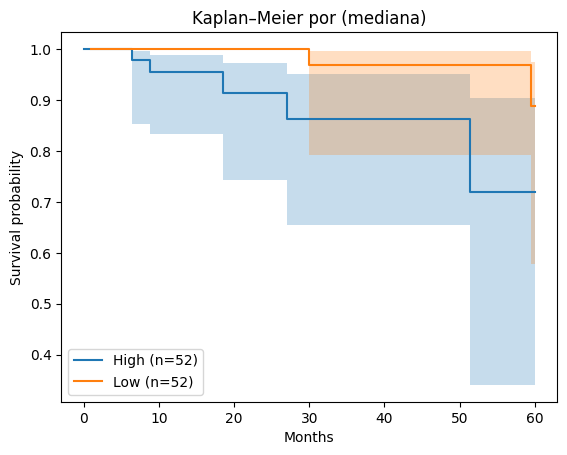

Log-rank: chi2=3.578, p=0.05857


In [137]:
model_cn.net.eval()
with torch.no_grad():
    risk_nn_test_cox_nnet = model_cn.net(
        torch.as_tensor(test_X, dtype=torch.float32)
    ).flatten()

list_risk_test_cox_nnet = risk_nn_test_cox_nnet.cpu().numpy().tolist()
chisq, p_value = k_m_cox(list_risk_test_cox_nnet, test_durations, test_events)

In [138]:
train_X_np = train_X.cpu().numpy()
train_durations_np = train_durations.cpu().numpy()
train_events_np = train_events.cpu().numpy()
test_X_np = test_X

train_X_np.shape, train_durations_np.shape, train_events_np.shape

((331, 1000), (331,), (331,))